
# Notebook 2 - Grafo de conhecimento

Este notebook mostra a transformação da base integrada em uma rede de relacionamentos.


In [1]:

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path("..").resolve()
df = pd.read_csv(BASE / "data/processed/base_integrada.csv")
df.head()


Matplotlib is building the font cache; this may take a moment.


,id_transacao,id_contrato,transacao_data,transacao_valor,transacao_tipo,id_cliente,id_produto,id_agencia,contrato_valor,contrato_data,cliente_nome,cpf,email,telefone,endereco,nome_agencia,cidade,estado,produto_nome,produto_tipo,taxa_juros,ano_mes,ano,mes,dia
0,1,14422,2024-09-16 23:50:58,10.16,Pagamento,812,27,65,7922.34,2026-01-04,Dr. João Miguel Pacheco,395.718.620-02,barrosluiz-miguel@example.net,+55 61 4651 3067,"Conjunto de Rodrigues, 74, Vila Petropolis, 14...",Agência 065,Sales,ES,Poupança 27,Poupança,2.02,2024-09,2024,9,16
1,2,6407,2024-04-12 18:00:52,12.20,Crédito,2254,7,60,93342.75,2025-04-26,André Melo,291.853.670-95,vpires@example.org,61 4518-1355,"Fazenda Farias, 583, Cinquentenário, 27080485 ...",Agência 060,Siqueira das Pedras,MG,Poupança 07,Poupança,2.64,2024-04,2024,4,12
2,3,8557,2024-08-01 02:42:22,5.00,Débito,1928,37,1,138573.42,2025-03-29,Srta. Maya Fernandes,305.249.618-24,kfarias@example.org,+55 21 0970-5926,"Área Monteiro, 848, Lagoinha Leblon, 00432-954...",Agência 001,Farias de Araújo,BA,Financiamento 37,Financiamento,3.82,2024-08,2024,8,1
3,4,11647,2024-04-18 20:50:01,5.00,Crédito,754,14,49,131719.88,2025-12-06,Joana Vargas,859.306.217-21,gustavo-henriquepires@example.com,+55 61 4038 8577,"Lago de Cavalcante, 1, Jaqueline, 13037667 Men...",Agência 049,Castro,GO,Financiamento 14,Financiamento,4.26,2024-04,2024,4,18
4,5,3620,2025-11-26 17:56:40,33.46,Crédito,1739,8,41,10066.39,2025-08-22,Sra. Sophie Sales,645.371.980-01,antony31@example.net,+55 (071) 4565-0305,"Residencial Yago Fogaça, Indaiá, 19205-562 Bor...",Agência 041,Farias da Prata,CE,Conta Corrente 08,Conta Corrente,3.78,2025-11,2025,11,26


## Etapa 1 - Reduzir para contratos únicos

In [2]:

unique = df[["id_contrato","id_cliente","cliente_nome","id_agencia","nome_agencia","id_produto","produto_nome"]].drop_duplicates()
unique.shape


(14734, 7)

## Etapa 2 - Construir o grafo

In [3]:

G = nx.Graph()
for _, row in unique.head(200).iterrows():
    c = f"cliente_{int(row['id_cliente'])}"
    a = f"agencia_{int(row['id_agencia'])}"
    p = f"produto_{int(row['id_produto'])}"
    co = f"contrato_{int(row['id_contrato'])}"
    G.add_node(c, label=row["cliente_nome"], group="cliente")
    G.add_node(a, label=row["nome_agencia"], group="agencia")
    G.add_node(p, label=row["produto_nome"], group="produto")
    G.add_node(co, label=f"Contrato {int(row['id_contrato'])}", group="contrato")
    G.add_edge(c, a)
    G.add_edge(c, co)
    G.add_edge(co, p)
G.number_of_nodes(), G.number_of_edges()


(507, 600)

## Etapa 3 - Visualizar uma amostra

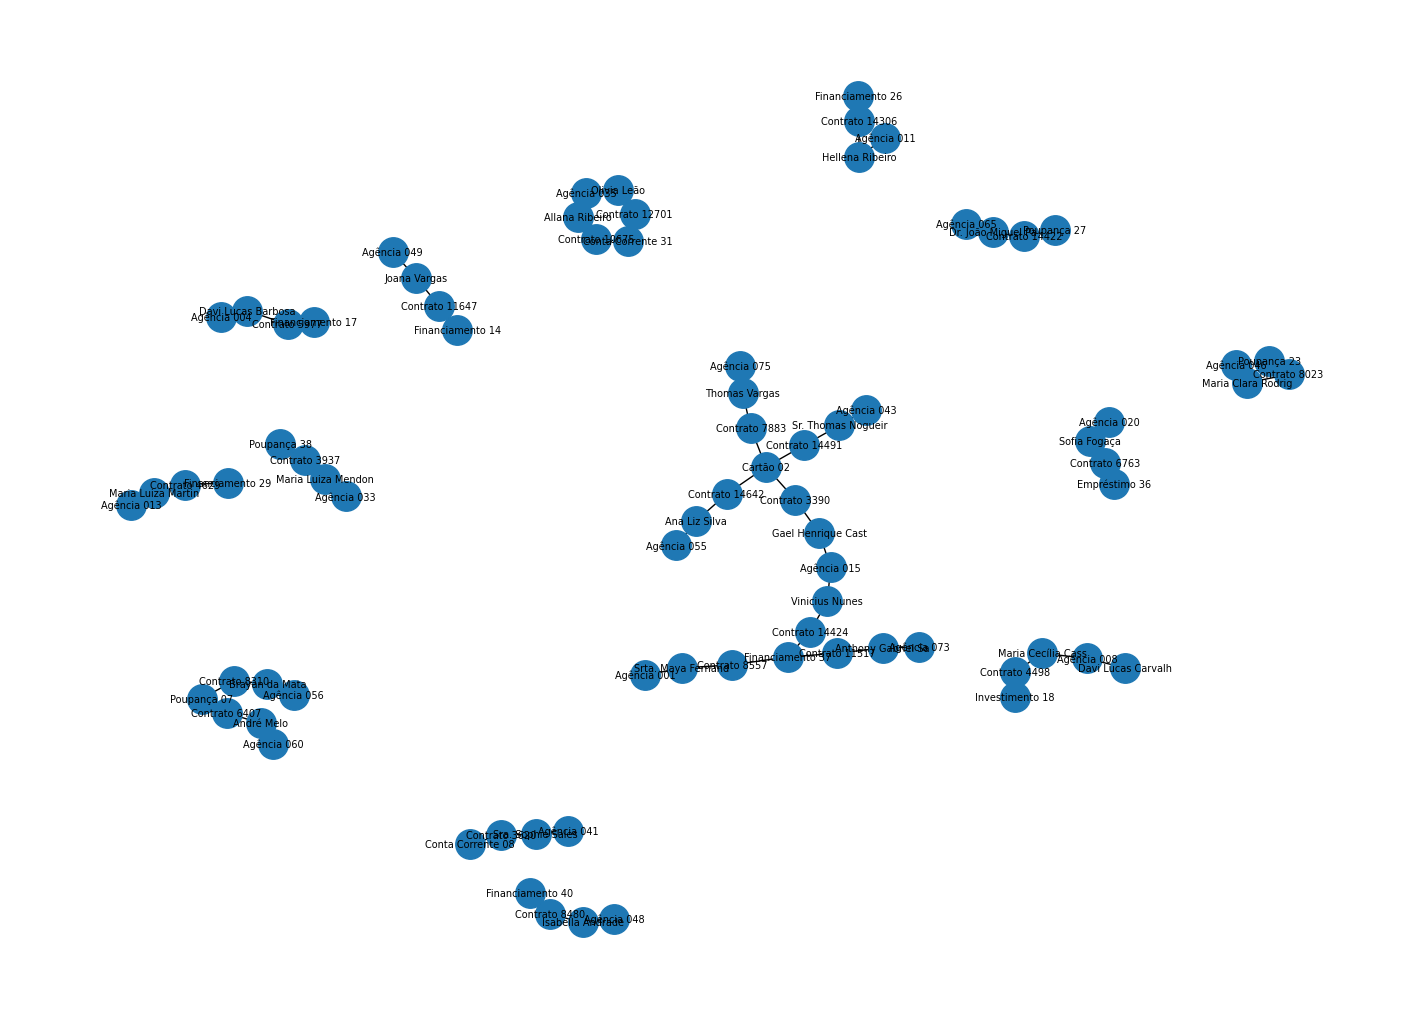

In [4]:

plt.figure(figsize=(14,10))
sg = G.subgraph(list(G.nodes())[:80])
pos = nx.spring_layout(sg, seed=42)
labels = {n: d["label"][:18] for n,d in sg.nodes(data=True)}
nx.draw(sg, pos, with_labels=False, node_size=450)
nx.draw_networkx_labels(sg, pos, labels=labels, font_size=7)
plt.show()
